# Experiment: CyEmbed Batch 4 Unt/Tr 6 Dosages Sweep

Objective:
- Run a reproducible CyEmbed hyperparameter sweep on `Batch4_Unt_Tr_6dosages_all_samples_GFPpos_GFPneg.csv`.
- Exclude core histones (`H2A`, `H2B`, `H3`, `H3.3`, `H4`), plus `GFP`, `CD45`, and `DNA` from training.
- Save ranked runs and outputs for downstream archetype analysis.

In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display



def _find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    for candidate in [resolved, *resolved.parents]:
        if (candidate / 'CyEmbed').exists():
            return candidate
    return resolved


PROJECT_ROOT_BOOTSTRAP = _find_project_root(Path.cwd())
if str(PROJECT_ROOT_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_BOOTSTRAP))

from CyEmbed.data import balanced_downsample_indices, extract_matrix, split_train_val_indices
from CyEmbed.train import build_sweep_configs, run_sweep

np.random.seed(7)
pd.set_option('display.max_columns', 200)
sns.set_context('notebook')


In [2]:
def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    for candidate in [resolved, *resolved.parents]:
        if (candidate / 'CyEmbed').exists():
            return candidate
    return resolved


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = Path('/Users/ronguy/Dropbox/WIS-CIMA colab - Analysis/summarized data/forGuy/Batch4_Unt_Tr_6dosages_all_samples_GFPpos_GFPneg.csv')
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'batch4_unt_tr_6dosages_gfppos_only_sweep'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DATA_CFG = {
    'metadata_columns': ['cell_id', 'sample_name', 'condition', 'sample_folder', 'GFP_group', 'source_file', 'batch'],
    'cell_id_col': 'cell_id',
    'sample_col': 'sample_name',
    'condition_col': 'condition',
    'condition_binary_col': 'condition_binary',
    'gfp_group_col': 'GFP_group',
    'gfp_positive_only': True,
    'gfp_positive_values': ['GFPpos', 'GFP+', 'pos', 'positive'],
    'max_cells': None,
    'na_strategy': 'median',  # 'median' or 'drop'
    'extra_exclude_markers': ['GFP', 'CD45', 'DNA'],
    'exclude_regex': [],
    'drop_low_mad_markers': False,
    'min_marker_mad': 1e-3,  # used only if drop_low_mad_markers=True
}

PREPROCESS_CFG = {
    'asinh_cofactor': None,
    'scaling': 'zscore',  # 'zscore', 'robust_zscore', or 'none'
    'min_scale': 0.1,
    'clip_abs_z': 25.0,
    'balanced_scaling_by_sample': False,
    'balanced_max_per_sample': 4000,
    'seed': 7,
}

SPLIT_CFG = {
    'val_fraction': 0.2,
    'seed': 7,
    'stratify_by': 'condition',  # 'condition', 'sample', or None
}

# Speed profile (default is fast; switch to 'thorough' when you want a deeper sweep).
SPEED_CFG = {
    'profile': 'thorough',  # 'fast' or 'thorough'
    'auto_batch_size': True,
    'batch_size_by_device': {'cuda': 4096, 'mps': 4096, 'cpu': 1024},
    'max_batch_size_cap': 4096,
    'fast_epochs': 1000,
    'fast_patience': 12,
    'fast_hidden_dims': [128, 64],
    'fast_prob_eval_samples': 1,
    'fast_deterministic': False,
    'fast_progress_epoch': False,
    'fast_progress_sweep': True,
    'fast_sweep_grid': {
        'K': [4,5,6,7],
        'd': [8],
        'lr': [1e-3, 5e-4],
        'tau': [0.8],
        'lambda_entropy': [0.0, 0.003],
    },
}

BASE_CONFIG = {
    'model_type': 'probabilistic',
    'decoder_type': 'factorized',
    'use_residual_latent': False,
    'residual_dim': 8,
    'hidden_dims': [256, 128],
    'epochs': 1000,
    'batch_size': 512,
    'lr': 1e-3,
    'weight_decay': 1e-6,
    'recon_loss_type': 'mse',
    'huber_delta': 1.0,
    'lambda_entropy': 0.0,
    'lambda_sep': 0.02,
    'lambda_balance': 0.0,
    'separation_mode': 'cosine_sq',
    'balance_mode': 'l2_uniform',
    'rbf_gamma': 1.0,
    'tau': 0.8,
    'beta_w': 5e-4,
    'beta_r': 0.0,
    'kl_warmup_epochs': 30,
    'prob_eval_mode': 'mean',
    'prob_eval_samples': 3,
    'early_stopping': True,
    'patience': 25,
    'min_delta': 1e-4,
    'restore_best_weights': True,
    'device': 'auto',
    'seed': 7,
    'deterministic': True,
    'progress_sweep': True,
    'progress_epoch': True,
    'print_every': 10,
    'skip_existing_runs': True,
}

SWEEP_GRID = {
    'K': [4,5,6,7],
    'd': [8],
    'lr': [1e-3, 5e-4],
    'tau': [0.8],
    'lambda_entropy': [0.0, 0.003],
}


def resolve_train_device_name(device_pref: str = 'auto') -> str:
    pref = str(device_pref).lower()
    try:
        import torch

        if pref in {'auto', 'best'}:
            if torch.cuda.is_available():
                return 'cuda'
            if torch.backends.mps.is_available():
                return 'mps'
            return 'cpu'
        if pref == 'cuda':
            return 'cuda' if torch.cuda.is_available() else resolve_train_device_name('auto')
        if pref == 'mps':
            return 'mps' if torch.backends.mps.is_available() else resolve_train_device_name('auto')
        if pref == 'cpu':
            return 'cpu'
        return pref
    except Exception:
        return 'cpu'


def apply_speed_profile(
    base_config: dict,
    sweep_grid: dict,
    speed_cfg: dict,
) -> tuple[dict, dict, str]:
    cfg = dict(base_config)
    grid = {k: list(v) for k, v in sweep_grid.items()}

    profile = str(speed_cfg.get('profile', 'fast')).lower()
    if profile == 'fast':
        cfg['epochs'] = int(speed_cfg['fast_epochs'])
        cfg['patience'] = int(speed_cfg['fast_patience'])
        cfg['hidden_dims'] = list(speed_cfg['fast_hidden_dims'])
        cfg['prob_eval_samples'] = int(speed_cfg['fast_prob_eval_samples'])
        cfg['deterministic'] = bool(speed_cfg['fast_deterministic'])
        cfg['progress_epoch'] = bool(speed_cfg['fast_progress_epoch'])
        cfg['progress_sweep'] = bool(speed_cfg['fast_progress_sweep'])
        grid = {k: list(v) for k, v in speed_cfg['fast_sweep_grid'].items()}

    resolved_device = resolve_train_device_name(cfg.get('device', 'auto'))
    if bool(speed_cfg.get('auto_batch_size', True)):
        recommended = int(speed_cfg['batch_size_by_device'].get(resolved_device, cfg['batch_size']))
        cap = int(speed_cfg.get('max_batch_size_cap', recommended))
        cfg['batch_size'] = int(min(cap, max(int(cfg['batch_size']), recommended)))

    return cfg, grid, resolved_device


BASE_CONFIG, SWEEP_GRID, RESOLVED_DEVICE = apply_speed_profile(BASE_CONFIG, SWEEP_GRID, SPEED_CFG)
N_SWEEP_RUNS = int(np.prod([len(v) for v in SWEEP_GRID.values()]))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_ROOT:  {OUTPUT_ROOT}')
print(f"Speed profile: {SPEED_CFG['profile']}")
print(f'Resolved train device: {RESOLVED_DEVICE}')
print(
    f"Effective config -> batch_size={BASE_CONFIG['batch_size']}, "
    f"epochs={BASE_CONFIG['epochs']}, patience={BASE_CONFIG['patience']}, "
    f"hidden_dims={BASE_CONFIG['hidden_dims']}, prob_eval_samples={BASE_CONFIG['prob_eval_samples']}"
)
print(f'Planned sweep runs: {N_SWEEP_RUNS}')


PROJECT_ROOT: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed
OUTPUT_ROOT:  /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep
Speed profile: thorough
Resolved train device: mps
Effective config -> batch_size=4096, epochs=1000, patience=25, hidden_dims=[256, 128], prob_eval_samples=3
Planned sweep runs: 16


In [3]:
CORE_HISTONE_MARKERS = {'h2a', 'h2b', 'h3', 'h33', 'h4'}


def canonicalize_marker(name: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(name).lower())


def make_unique_ids(values: list[str] | pd.Series) -> list[str]:
    counts: dict[str, int] = {}
    out: list[str] = []
    for idx, value in enumerate(values):
        base = str(value).strip() if pd.notna(value) else ''
        if not base:
            base = f'row_{idx}'
        seen = counts.get(base, 0)
        out.append(base if seen == 0 else f'{base}__dup{seen}')
        counts[base] = seen + 1
    return out


def is_gfp_positive(value: object, positive_values: list[str]) -> bool:
    canon = canonicalize_marker(str(value))
    targets = {canonicalize_marker(v) for v in positive_values}
    return canon in targets


def normalize_condition_label(value: object) -> str:
    text = str(value).strip()
    canon = canonicalize_marker(text)
    if canon == '' or canon == 'nan':
        return 'Unknown'
    if canon in {'unt', 'untreated'} or canon.startswith('untreated') or canon.startswith('unt'):
        return 'Untreated'
    if canon in {'tr', 'treated'} or canon.startswith('treated') or canon.startswith('tr'):
        return 'Treated'
    return text


if not DATA_PATH.exists():
    raise FileNotFoundError(f'CSV not found: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
raw_rows_total = int(raw_df.shape[0])

if DATA_CFG.get('gfp_positive_only', False):
    gfp_col = DATA_CFG.get('gfp_group_col', 'GFP_group')
    if gfp_col not in raw_df.columns:
        raise KeyError(f"GFP filter requested but column '{gfp_col}' not found in CSV.")
    gfp_mask = raw_df[gfp_col].map(lambda v: is_gfp_positive(v, DATA_CFG['gfp_positive_values']))
    raw_df = raw_df.loc[gfp_mask].copy()

raw_rows_after_gfp_filter = int(raw_df.shape[0])
if raw_rows_after_gfp_filter == 0:
    raise ValueError('No rows remained after GFP+ filtering. Check DATA_CFG gfp settings.')

if DATA_CFG['max_cells'] is not None:
    raw_df = raw_df.head(int(DATA_CFG['max_cells'])).copy()

non_numeric_cols = [c for c in raw_df.columns if not pd.api.types.is_numeric_dtype(raw_df[c])]
metadata_cols = sorted(set(DATA_CFG['metadata_columns'] + non_numeric_cols).intersection(raw_df.columns))
candidate_marker_cols = [c for c in raw_df.columns if c not in metadata_cols]

candidate_numeric_df = raw_df[candidate_marker_cols].apply(pd.to_numeric, errors='coerce')
numeric_keep = candidate_numeric_df.notna().any(axis=0)
candidate_numeric_df = candidate_numeric_df.loc[:, numeric_keep]

dropped_non_numeric_candidates = sorted(set(candidate_marker_cols) - set(candidate_numeric_df.columns))

manual_excludes = {canonicalize_marker(v) for v in DATA_CFG['extra_exclude_markers']}
manual_excludes = manual_excludes.union(CORE_HISTONE_MARKERS)
regex_rules = [re.compile(pat, flags=re.IGNORECASE) for pat in DATA_CFG['exclude_regex']]


def should_exclude_marker(col: str) -> bool:
    c = canonicalize_marker(col)
    if c in manual_excludes:
        return True
    return any(rule.search(str(col)) for rule in regex_rules)


kept_marker_cols = [c for c in candidate_numeric_df.columns if not should_exclude_marker(c)]
excluded_marker_cols = [c for c in candidate_numeric_df.columns if should_exclude_marker(c)]

marker_df = candidate_numeric_df[kept_marker_cols].copy()


<Axes: xlabel='CD109', ylabel='Count'>

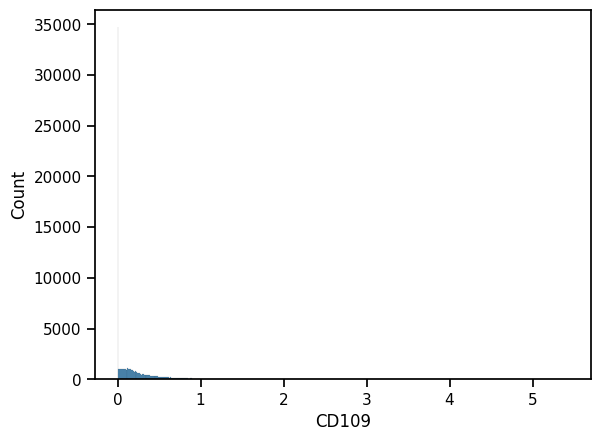

In [4]:
sns.histplot(marker_df.CD109)

In [5]:
if DATA_CFG['na_strategy'] == 'median':
    marker_df = marker_df.fillna(marker_df.median(numeric_only=True))
    row_keep = np.ones(marker_df.shape[0], dtype=bool)
elif DATA_CFG['na_strategy'] == 'drop':
    row_keep = (~marker_df.isna().any(axis=1)).to_numpy()
    marker_df = marker_df.loc[row_keep].copy()
else:
    raise ValueError("DATA_CFG['na_strategy'] must be 'median' or 'drop'.")

# Optional: drop near-constant markers (disabled by default).
marker_median = marker_df.median(axis=0, numeric_only=True)
marker_mad = (marker_df - marker_median).abs().median(axis=0, numeric_only=True)
low_mad_threshold = float(DATA_CFG['min_marker_mad'])
if DATA_CFG.get('drop_low_mad_markers', True):
    dropped_low_mad_markers = marker_mad[marker_mad <= low_mad_threshold].index.astype(str).tolist()
else:
    dropped_low_mad_markers = []

if dropped_low_mad_markers:
    marker_df = marker_df.drop(columns=dropped_low_mad_markers)
    kept_marker_cols = [c for c in kept_marker_cols if c not in set(dropped_low_mad_markers)]

marker_df = marker_df.reset_index(drop=True)
meta_df = raw_df.loc[row_keep, metadata_cols].copy().reset_index(drop=True)

if DATA_CFG['cell_id_col'] in raw_df.columns:
    raw_cell_values = raw_df.loc[row_keep, DATA_CFG['cell_id_col']].reset_index(drop=True)
else:
    raw_cell_values = pd.Series([f'cell_{i}' for i in range(int(row_keep.sum()))])

unique_cell_ids = make_unique_ids(raw_cell_values)
if 'cell_id' in meta_df.columns:
    meta_df['cell_id'] = unique_cell_ids
else:
    meta_df.insert(0, 'cell_id', unique_cell_ids)

sample_col = DATA_CFG['sample_col'] if DATA_CFG['sample_col'] in meta_df.columns else None
condition_col_raw = DATA_CFG['condition_col'] if DATA_CFG['condition_col'] in meta_df.columns else None
condition_binary_col = DATA_CFG.get('condition_binary_col', 'condition_binary')

if condition_col_raw is not None:
    meta_df[condition_binary_col] = meta_df[condition_col_raw].map(normalize_condition_label)
    condition_col = condition_binary_col
else:
    condition_col = None

sample_ids = meta_df[sample_col].astype(str).to_numpy() if sample_col is not None else None
condition_ids = meta_df[condition_col].astype(str).to_numpy() if condition_col is not None else None

bundle = extract_matrix(
    matrix=marker_df.to_numpy(dtype=np.float32),
    marker_names=kept_marker_cols,
    cell_ids=unique_cell_ids,
    sample_ids=sample_ids,
    cluster_ids=condition_ids,
)

variability_report = pd.DataFrame(
    {
        'marker': marker_mad.index.astype(str),
        'mad': marker_mad.to_numpy(),
        'dropped_low_mad': marker_mad.index.astype(str).isin(set(dropped_low_mad_markers)),
    }
).sort_values('mad', ascending=True)
variability_path = OUTPUT_ROOT / 'marker_variability_report.csv'
variability_report.to_csv(variability_path, index=False)

metadata_path = OUTPUT_ROOT / 'metadata_aligned.csv'
meta_df.to_csv(metadata_path, index=False)

print(f'Raw rows before GFP filter: {raw_rows_total:,}')
print(f'Rows after GFP+ filter: {raw_rows_after_gfp_filter:,}')
print(f'Rows used for training: {bundle.X.shape[0]:,}')
print(f'Markers used: {bundle.X.shape[1]}')
print(f'Markers excluded by name/rule: {len(excluded_marker_cols)}')
print(f'Markers dropped for low MAD (<= {low_mad_threshold}): {len(dropped_low_mad_markers)}')
if dropped_low_mad_markers:
    print(dropped_low_mad_markers)
print(f'Columns dropped as non-numeric marker candidates: {dropped_non_numeric_candidates}')
print('Excluded markers list:')
print(excluded_marker_cols)
print(f'Sample metadata present: {bundle.sample_ids is not None}')
print(f'Condition metadata present: {bundle.cluster_ids is not None}')
if condition_col is not None:
    print('Condition counts (treated vs untreated):')
    print(meta_df[condition_col].value_counts(dropna=False).to_dict())
print(f'Saved aligned metadata: {metadata_path}')
print(f'Saved marker variability report: {variability_path}')
display(meta_df.head(3))
display(variability_report.head(15))


Raw rows before GFP filter: 238,289
Rows after GFP+ filter: 71,100
Rows used for training: 71,100
Markers used: 34
Markers excluded by name/rule: 7
Markers dropped for low MAD (<= 0.001): 0
Columns dropped as non-numeric marker candidates: ['ACSS2', 'CD133', 'CXCR4', 'DLL3', 'KLF4', 'KRT7', 'MHC-II', 'S100A4']
Excluded markers list:
['CD45', 'DNA', 'GFP', 'H3', 'H3.3', 'H4', 'H2A']
Sample metadata present: True
Condition metadata present: True
Condition counts (treated vs untreated):
{'Untreated': 55181, 'Treated': 15919}
Saved aligned metadata: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep/metadata_aligned.csv
Saved marker variability report: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep/marker_variability_report.csv


,GFP_group,batch,cell_id,condition,sample_folder,sample_name,source_file,condition_binary
0,GFPpos,batch_4,A8_4,Untreated,1351_unt,A8,normalized_gated_transformed_1351_unt_GFPpos_g...,Untreated
1,GFPpos,batch_4,A8_5,Untreated,1351_unt,A8,normalized_gated_transformed_1351_unt_GFPpos_g...,Untreated
2,GFPpos,batch_4,A8_11,Untreated,1351_unt,A8,normalized_gated_transformed_1351_unt_GFPpos_g...,Untreated


,marker,mad,dropped_low_mad
31,SLC44A4,0.000000,False
5,EpCAM,0.019992,False
0,CD109,0.020075,False
29,pH2AX,0.113911,False
8,H2AK119ub,0.178485,False
23,KRT17,0.240847,False
2,CD44,0.259200,False
20,H4K16ac,0.264331,False
1,CD24,0.316043,False
4,EZH2,0.435267,False


In [6]:
fit_sample_ids = bundle.sample_ids if PREPROCESS_CFG['balanced_scaling_by_sample'] else None
balanced_max = PREPROCESS_CFG['balanced_max_per_sample'] if PREPROCESS_CFG['balanced_scaling_by_sample'] else None

X_for_scaling = np.asarray(bundle.X, dtype=np.float32)
asinh_cofactor = PREPROCESS_CFG.get('asinh_cofactor', None)
if asinh_cofactor is not None:
    X_for_scaling = np.arcsinh(X_for_scaling / float(asinh_cofactor)).astype(np.float32)

if fit_sample_ids is not None and balanced_max is not None:
    scaler_fit_idx = balanced_downsample_indices(
        labels=fit_sample_ids,
        max_per_group=int(balanced_max),
        random_state=int(PREPROCESS_CFG['seed']),
    )
else:
    scaler_fit_idx = np.arange(X_for_scaling.shape[0], dtype=np.int64)

x_fit = X_for_scaling[scaler_fit_idx]
scaling_mode = PREPROCESS_CFG['scaling']
if scaling_mode == 'robust_zscore':
    center = np.median(x_fit, axis=0)
    mad = np.median(np.abs(x_fit - center[None, :]), axis=0)
    raw_scale = 1.4826 * mad
elif scaling_mode == 'zscore':
    center = np.mean(x_fit, axis=0)
    raw_scale = np.std(x_fit, axis=0)
elif scaling_mode == 'none':
    center = np.zeros(x_fit.shape[1], dtype=np.float32)
    raw_scale = np.ones(x_fit.shape[1], dtype=np.float32)
else:
    raise ValueError("PREPROCESS_CFG['scaling'] must be one of {'robust_zscore', 'zscore', 'none'}")

min_scale = float(PREPROCESS_CFG.get('min_scale', 1e-2))
scale = np.maximum(raw_scale, min_scale)
X_processed = ((X_for_scaling - center[None, :]) / scale[None, :]).astype(np.float32)

clip_abs_z = PREPROCESS_CFG.get('clip_abs_z', None)
if clip_abs_z is not None:
    X_processed = np.clip(X_processed, -float(clip_abs_z), float(clip_abs_z)).astype(np.float32)

scaler_state = {
    'mode': scaling_mode,
    'asinh_cofactor': asinh_cofactor,
    'min_scale': min_scale,
    'clip_abs_z': clip_abs_z,
    'center': center.tolist(),
    'scale': scale.tolist(),
}

floored_count = int(np.sum(raw_scale < min_scale))
baseline_mse = float(np.mean(X_processed**2))
print(f'Scaler mode: {scaling_mode}')
print(f'Scaler fit size: {len(scaler_fit_idx):,} rows')
print(f'asinh cofactor: {asinh_cofactor}')
print(f'scale floor (min_scale): {min_scale}')
print(f'n markers floored: {floored_count}/{len(scale)}')
print(f'Processed |X| q99: {np.quantile(np.abs(X_processed), 0.99):.3f}')
print(f'Processed |X| max: {np.max(np.abs(X_processed)):.3f}')
print(f'Baseline MSE (predict 0): {baseline_mse:.4f}')

stratify_labels = None
stratify_mode = SPLIT_CFG['stratify_by']
if stratify_mode == 'sample' and bundle.sample_ids is not None:
    stratify_labels = bundle.sample_ids
elif stratify_mode == 'condition' and bundle.cluster_ids is not None:
    stratify_labels = bundle.cluster_ids

train_idx, val_idx = split_train_val_indices(
    n_cells=X_processed.shape[0],
    val_fraction=float(SPLIT_CFG['val_fraction']),
    seed=int(SPLIT_CFG['seed']),
    stratify_labels=stratify_labels,
)

print(f'Train cells: {train_idx.size:,} | Val cells: {val_idx.size:,}')


Scaler mode: zscore
Scaler fit size: 71,100 rows
asinh cofactor: None
scale floor (min_scale): 0.1
n markers floored: 0/34
Processed |X| q99: 2.942
Processed |X| max: 25.000
Baseline MSE (predict 0): 0.9996
Train cells: 56,880 | Val cells: 14,220


In [7]:
sweep_configs = build_sweep_configs(SWEEP_GRID)
print(f'Planned runs: {len(sweep_configs)}')
display(pd.DataFrame(sweep_configs).head(10))

# Remove stale empty run directories so skip_existing_runs does not get stuck.
stale_empty_dirs = []
for run_dir in sorted(OUTPUT_ROOT.glob('run_*')):
    if not run_dir.is_dir():
        continue
    if (run_dir / 'config.json').exists() or (run_dir / 'summary_metrics.json').exists():
        continue
    if not any(run_dir.iterdir()):
        stale_empty_dirs.append(run_dir)

for run_dir in stale_empty_dirs:
    run_dir.rmdir()
if stale_empty_dirs:
    print(f'Removed {len(stale_empty_dirs)} stale empty run directories.')

notebook_config = {
    'data_path': str(DATA_PATH),
    'output_root': str(OUTPUT_ROOT),
    'data_cfg': DATA_CFG,
    'preprocess_cfg': PREPROCESS_CFG,
    'split_cfg': SPLIT_CFG,
    'speed_cfg': SPEED_CFG,
    'resolved_device': RESOLVED_DEVICE,
    'base_config': BASE_CONFIG,
    'sweep_grid': SWEEP_GRID,
    'used_markers': kept_marker_cols,
    'excluded_markers': excluded_marker_cols,
    'sample_col_resolved': sample_col,
    'condition_col_resolved': condition_col,
    'condition_col_raw_resolved': condition_col_raw,
    'gfp_filter': {
        'enabled': bool(DATA_CFG.get('gfp_positive_only', False)),
        'gfp_group_col': DATA_CFG.get('gfp_group_col'),
        'gfp_positive_values': DATA_CFG.get('gfp_positive_values'),
        'rows_before_filter': raw_rows_total,
        'rows_after_filter': raw_rows_after_gfp_filter,
    },
    'dropped_low_mad_markers': dropped_low_mad_markers,
}
with (OUTPUT_ROOT / 'notebook_config.json').open('w', encoding='utf-8') as f:
    json.dump(notebook_config, f, indent=2)

summary_df = run_sweep(
    x=X_processed,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=OUTPUT_ROOT,
    base_config=BASE_CONFIG,
    sweep_configs=sweep_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler_state,
)

summary_df = summary_df.sort_values('val_recon', ascending=True).reset_index(drop=True)
ranked_path = OUTPUT_ROOT / 'sweep_summary_sorted.csv'
summary_df.to_csv(ranked_path, index=False)
print(f'Saved ranked sweep summary: {ranked_path}')
display(summary_df.head(20))


Planned runs: 16


,K,d,lr,tau,lambda_entropy
0,4,8,0.0010,0.8,0.000
1,4,8,0.0010,0.8,0.003
2,4,8,0.0005,0.8,0.000
3,4,8,0.0005,0.8,0.003
4,5,8,0.0010,0.8,0.000
5,5,8,0.0010,0.8,0.003
6,5,8,0.0005,0.8,0.000
7,5,8,0.0005,0.8,0.003
8,6,8,0.0010,0.8,0.000
9,6,8,0.0010,0.8,0.003


Sweep:   0%|          | 0/16 [00:00<?, ?it/s]

[run_probabilistic_43ac841e85] Using device: mps


run_probabilistic_43ac841e85 epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

...

run_probabilistic_ec95208321 epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

[run_probabilistic_ec95208321] Early stopping at epoch 582 (patience=25, best_epoch=557, best_val_recon=0.40383)
[run_probabilistic_6c060e7e84] Using device: mps


run_probabilistic_6c060e7e84 epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

[run_probabilistic_6c060e7e84] Early stopping at epoch 682 (patience=25, best_epoch=657, best_val_recon=0.40372)
Saved ranked sweep summary: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep/sweep_summary_sorted.csv


,run_id,run_dir,model_type,decoder_type,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_0346a13f48,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0010,4096,mse,0.000,0.02,0.0,0.8,25,379,True,0.403572,0.419171,0.759629,1.802439,0.030305,0,0.000844,0.000000,22.714696,0.0
1,run_probabilistic_cb76a73638,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0010,4096,mse,0.003,0.02,0.0,0.8,25,391,True,0.403689,0.424071,0.761091,1.788291,0.034643,0,0.000774,0.000000,22.439897,0.0
2,run_probabilistic_6c060e7e84,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0005,4096,mse,0.003,0.02,0.0,0.8,25,657,True,0.403717,0.424113,0.760816,1.788394,0.035489,0,0.000492,0.000000,22.496164,0.0
3,run_probabilistic_ec95208321,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0005,4096,mse,0.000,0.02,0.0,0.8,25,557,True,0.403833,0.419604,0.759293,1.809523,0.021029,0,0.000703,0.000000,22.700294,0.0
4,run_probabilistic_38e560ece9,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,6,8,256-128,0.0010,4096,mse,0.003,0.02,0.0,0.8,25,475,True,0.440352,0.459740,0.733276,1.649602,0.039048,0,0.003516,0.000000,19.756464,0.0
5,run_probabilistic_3f4640efda,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,6,8,256-128,0.0010,4096,mse,0.000,0.02,0.0,0.8,25,396,True,0.440415,0.454936,0.733311,1.669566,0.025092,0,0.002954,0.000000,19.962373,0.0
6,run_probabilistic_8f9fbb1f66,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,6,8,256-128,0.0005,4096,mse,0.000,0.02,0.0,0.8,25,630,True,0.440445,0.454980,0.733293,1.668250,0.024211,0,0.002110,0.000000,19.884337,0.0
7,run_probabilistic_c038d9d2cb,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,6,8,256-128,0.0005,4096,mse,0.003,0.02,0.0,0.8,25,715,True,0.440548,0.459709,0.733124,1.648117,0.039684,0,0.002813,0.000000,19.740103,0.0
8,run_probabilistic_cacb57647a,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,5,8,256-128,0.0010,4096,mse,0.000,0.02,0.0,0.8,25,276,True,0.481919,0.496070,0.701572,1.472295,0.042423,0,0.023558,0.000000,16.773351,0.0
9,run_probabilistic_d96003f2b4,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,5,8,256-128,0.0005,4096,mse,0.000,0.02,0.0,0.8,25,431,True,0.482006,0.496143,0.701326,1.469163,0.039862,0,0.020816,0.000000,16.716934,0.0


,run_id,run_dir,model_type,decoder_type,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_0346a13f48,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.001,4096,mse,0.0,0.02,0.0,0.8,25,379,True,0.403572,0.419171,0.759629,1.802439,0.030305,0,0.000844,0.0,22.714696,0.0


Best run directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep/run_probabilistic_0346a13f48


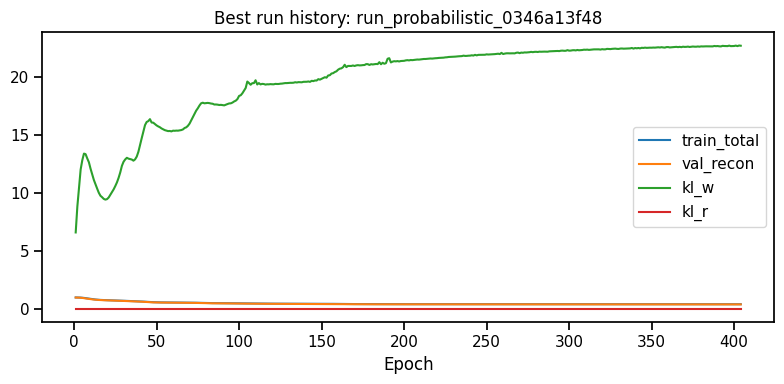

In [8]:
if summary_df.empty:
    raise RuntimeError('Sweep produced no rows. Check logs above.')

best_row = summary_df.iloc[0]
display(best_row.to_frame().T)

best_run_dir = Path(best_row['run_dir'])
best_history = pd.read_csv(best_run_dir / 'history.csv')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_history['epoch'], best_history['loss'], label='train_total')
ax.plot(best_history['epoch'], best_history['val_recon'], label='val_recon')
if 'kl_w' in best_history.columns:
    ax.plot(best_history['epoch'], best_history['kl_w'], label='kl_w')
if 'kl_r' in best_history.columns:
    ax.plot(best_history['epoch'], best_history['kl_r'], label='kl_r')
ax.set_title(f"Best run history: {best_row['run_id']}")
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()

print(f"Best run directory: {best_run_dir}")


## Next steps

- Open `02_batch4_unt_tr_6dosages_analysis.ipynb`.
- Keep `override_run_dir=None` to use the top-ranked run, or set an explicit run override.